# Network attack anomaly detection

Download dataset file from https://www.kaggle.com/datasets/chethuhn/network-intrusion-dataset?resource=download , extract and place Friday-WorkingHours-Afternoon-DDos.pcap_ISCX next to this notebook. This is the Intrusion Detection Evaluation Dataset (CIC-IDS2017) you can find the dataset by this link - https://www.unb.ca/cic/datasets/ids-2017.html

In [1]:
# downloading the dataset

from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report,
    precision_score,
    recall_score,
    f1_score,
)

# Dataset file located next to this notebook
dataset_path = Path("Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")

# Load dataset
df = pd.read_csv(dataset_path)

# Clean column names: CICIDS datasets often contain leading spaces in column names
df.columns = df.columns.str.strip()

print("Dataset loaded successfully.")
print(f"Shape: {df.shape[0]:,} rows × {df.shape[1]:,} columns")

display(df.head())

Dataset loaded successfully.
Shape: 225,745 rows × 79 columns


,Destination Port,Flow Duration,Total Fwd Packets,Total Backward Packets,Total Length of Fwd Packets,Total Length of Bwd Packets,Fwd Packet Length Max,Fwd Packet Length Min,Fwd Packet Length Mean,Fwd Packet Length Std,...,min_seg_size_forward,Active Mean,Active Std,Active Max,Active Min,Idle Mean,Idle Std,Idle Max,Idle Min,Label
0,54865,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
1,55054,109,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
2,55055,52,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
3,46236,34,1,1,6,6,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN
4,54863,3,2,0,12,0,6,6,6.0,0.0,...,20,0.0,0.0,0,0,0.0,0.0,0,0,BENIGN


In [2]:
# listing the columns

print("Column names:")
for i, col in enumerate(df.columns, start=1):
    print(f"{i:02d}. {col}")

print("\nDataset info:")
df.info()

Column names:
01. Destination Port
02. Flow Duration
03. Total Fwd Packets
04. Total Backward Packets
05. Total Length of Fwd Packets
06. Total Length of Bwd Packets
07. Fwd Packet Length Max
08. Fwd Packet Length Min
09. Fwd Packet Length Mean
10. Fwd Packet Length Std
11. Bwd Packet Length Max
12. Bwd Packet Length Min
13. Bwd Packet Length Mean
14. Bwd Packet Length Std
15. Flow Bytes/s
16. Flow Packets/s
17. Flow IAT Mean
18. Flow IAT Std
19. Flow IAT Max
20. Flow IAT Min
21. Fwd IAT Total
22. Fwd IAT Mean
23. Fwd IAT Std
24. Fwd IAT Max
25. Fwd IAT Min
26. Bwd IAT Total
27. Bwd IAT Mean
28. Bwd IAT Std
29. Bwd IAT Max
30. Bwd IAT Min
31. Fwd PSH Flags
32. Bwd PSH Flags
33. Fwd URG Flags
34. Bwd URG Flags
35. Fwd Header Length
36. Bwd Header Length
37. Fwd Packets/s
38. Bwd Packets/s
39. Min Packet Length
40. Max Packet Length
41. Packet Length Mean
42. Packet Length Std
43. Packet Length Variance
44. FIN Flag Count
45. SYN Flag Count
46. RST Flag Count
47. PSH Flag Count
48. ACK F

In [3]:
# checking what we have for labeling

if "Label" in df.columns:
    label_counts = df["Label"].value_counts()
    label_percent = df["Label"].value_counts(normalize=True) * 100

    label_summary = pd.DataFrame({
        "count": label_counts,
        "percent": label_percent
    })

    print("Label distribution:")
    display(label_summary)
else:
    print("Column 'Label' was not found.")

Label distribution:


,count,percent
Label,,
DDoS,128027,56.713105
BENIGN,97718,43.286895


In [4]:
import os
os.environ["KERAS_BACKEND"] = "torch"

In [5]:
# Training and evaluating the model

import numpy as np
import pandas as pd
import keras
from keras import layers
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# check the backend

print("Keras:", keras.__version__)
print("Backend:", keras.backend.backend())

# Load dataset
df = pd.read_csv("Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv")
df.columns = df.columns.str.strip()

df = df.replace([np.inf, -np.inf], np.nan)

print(df["Label"].value_counts())

# Binary target: 0 = BENIGN, 1 = DDoS / attack
y = (df["Label"].str.upper() != "BENIGN").astype(int)

# Features only: remove Label
X_df = df.drop(columns=["Label"])

# If there are categorical columns, one-hot encode them
X_df = pd.get_dummies(X_df, drop_first=False)

# Fill missing values
X_df = X_df.fillna(X_df.median(numeric_only=True))

# Save feature names
feature_names = X_df.columns.to_list()

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_df).astype("float32")

print("Feature matrix:", X_scaled.shape)
print("Labels:", y.value_counts())

# training the autoencoder only on benign records

X_benign = X_scaled[y.values == 0]
X_attack = X_scaled[y.values == 1]

X_train_benign, X_val_benign = train_test_split(
    X_benign,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("Benign train:", X_train_benign.shape)
print("Benign validation:", X_val_benign.shape)
print("Attack records:", X_attack.shape)

input_dim = X_train_benign.shape[1]
latent_dim = 16

inputs = keras.Input(shape=(input_dim,))

x = layers.Dense(64, activation="relu")(inputs)
x = layers.Dense(32, activation="relu")(x)

latent = layers.Dense(latent_dim, activation="relu", name="latent_space")(x)

x = layers.Dense(32, activation="relu")(latent)
x = layers.Dense(64, activation="relu")(x)

outputs = layers.Dense(input_dim, activation="linear")(x)

autoencoder = keras.Model(inputs, outputs, name="ddos_autoencoder")

autoencoder.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="mse"
)

autoencoder.summary()

history = autoencoder.fit(
    X_train_benign,
    X_train_benign,
    validation_data=(X_val_benign, X_val_benign),
    epochs=20,
    batch_size=256,
    verbose=1
)

Keras: 3.15.0
Backend: torch
Label
DDoS      128027
BENIGN     97718
Name: count, dtype: int64
Feature matrix: (225745, 78)
Labels: Label
1    128027
0     97718
Name: count, dtype: int64
Benign train: (78174, 78)
Benign validation: (19544, 78)
Attack records: (128027, 78)


Model: "ddos_autoencoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 78)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         5,056 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_space (Dense)            │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │           544 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 64)             │         2,112 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 78)             │         5,070 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 15,390 (60.12 KB)

 Trainable params: 15,390 (60.12 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.5511 - val_loss: 0.2482
Epoch 2/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.1613 - val_loss: 0.1265
Epoch 3/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.1004 - val_loss: 0.0802
Epoch 4/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0757 - val_loss: 0.0684
Epoch 5/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0634 - val_loss: 0.0605
Epoch 6/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0663 - val_loss: 0.0546
Epoch 7/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0494 - val_loss: 0.0744
Epoch 8/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 0.0460 - val_loss: 0.0494
Epoch 9/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0465 - val_loss: 0.0417
Epoch 10/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0374 - val_loss: 0.0381
Epoch 11/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 0.0359 - val_loss: 0.0416
Epoch 12/20
306/306 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step

### Early stopping

I wasn't adding early stopping 'cause I was checking manually if the validation loss is continously decreasing

Threshold: 0.06119947
Mean benign validation error: 0.034291863
Std benign validation error: 0.800001


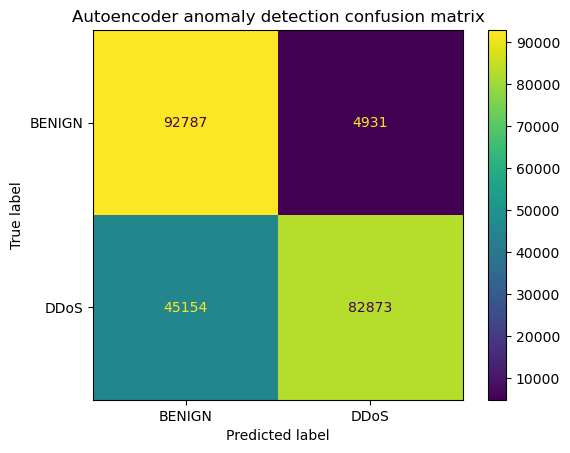

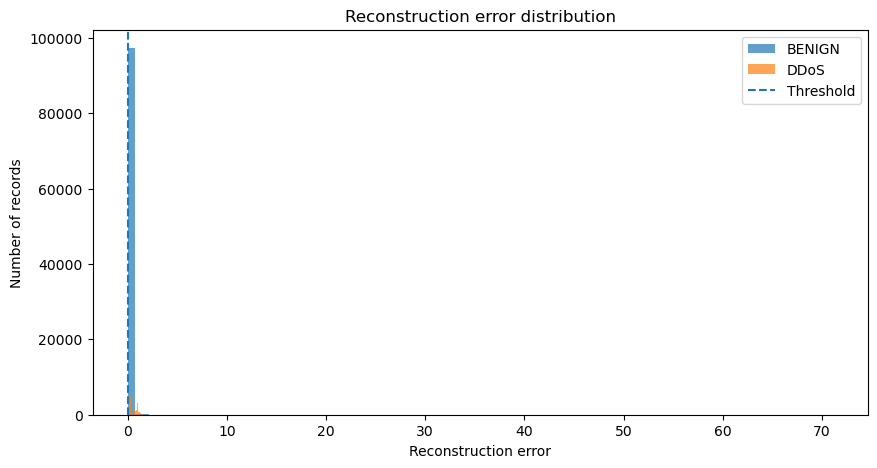

In [6]:
# the bird view

def reconstruction_errors(model, X):
    X_pred = model.predict(X, batch_size=1024, verbose=0)
    errors = np.mean(np.square(X - X_pred), axis=1)
    return errors

val_benign_errors = reconstruction_errors(autoencoder, X_val_benign)

threshold = np.percentile(val_benign_errors, 95)

print("Threshold:", threshold)
print("Mean benign validation error:", val_benign_errors.mean())
print("Std benign validation error:", val_benign_errors.std())

all_errors = reconstruction_errors(autoencoder, X_scaled)

y_true = y.values
y_pred = (all_errors > threshold).astype(int)

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["BENIGN", "DDoS"]
)

disp.plot(values_format="d")
plt.title("Autoencoder anomaly detection confusion matrix")
plt.show()

errors_df = pd.DataFrame({
    "reconstruction_error": all_errors,
    "true_label": np.where(y_true == 0, "BENIGN", "DDoS"),
    "predicted_label": np.where(y_pred == 0, "BENIGN", "DDoS")
})

plt.figure(figsize=(10, 5))
plt.hist(errors_df[errors_df["true_label"] == "BENIGN"]["reconstruction_error"], bins=100, alpha=0.7, label="BENIGN")
plt.hist(errors_df[errors_df["true_label"] == "DDoS"]["reconstruction_error"], bins=100, alpha=0.7, label="DDoS")
plt.axvline(threshold, linestyle="--", label="Threshold")
plt.xlabel("Reconstruction error")
plt.ylabel("Number of records")
plt.title("Reconstruction error distribution")
plt.legend()
plt.show()